<a href="https://colab.research.google.com/github/Netraa07/Assignment_1/blob/main/WEEK_2_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [1]:
from google.colab import files

uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (2).csv


In [3]:
import pandas as pd

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (2640, 12)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
print("Missing Values:\n")
df.isnull().sum()

Missing Values:



,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

Dataset Shape: (2640, 12)


In [13]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [14]:
df = df.sort_values("Date")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


In [15]:
df.dtypes

,0
Year,int64
Month,int64
Region,object
Model,object
Estimated_Deliveries,int64
Production_Units,int64
Avg_Price_USD,float64
Battery_Capacity_kWh,int64
Range_km,int64
CO2_Saved_tons,float64


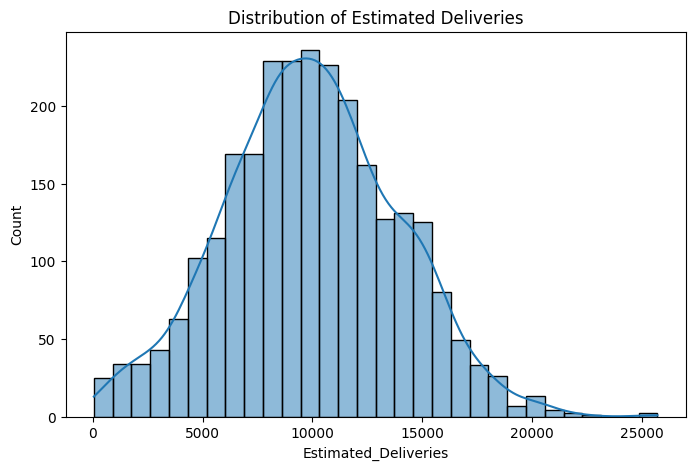

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], bins=30, kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.show()

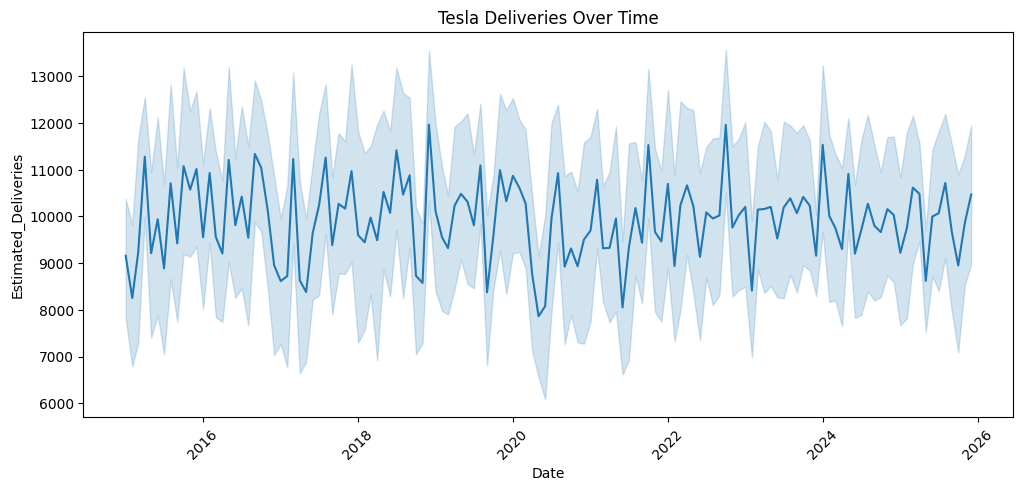

In [17]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x="Date", y="Estimated_Deliveries")
plt.title("Tesla Deliveries Over Time")
plt.xticks(rotation=45)
plt.show()

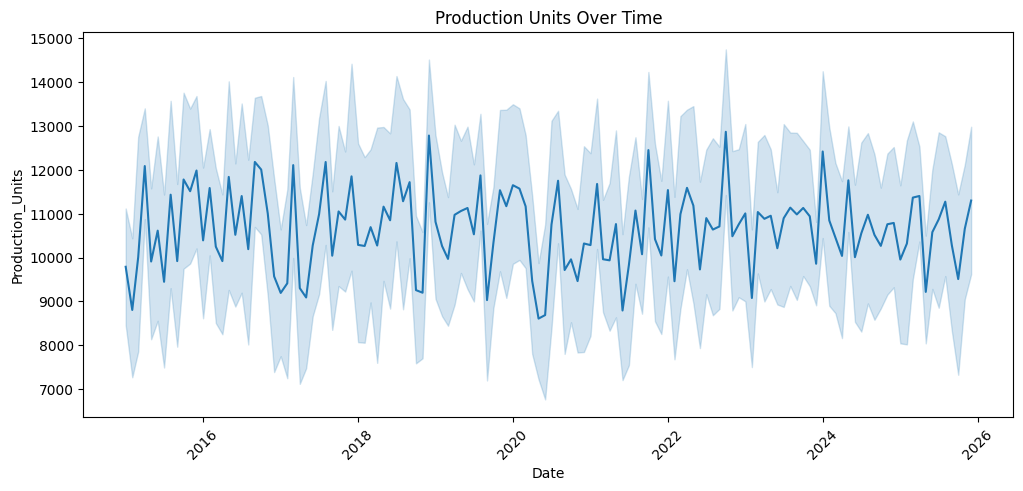

In [18]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x="Date", y="Production_Units")
plt.title("Production Units Over Time")
plt.xticks(rotation=45)
plt.show()

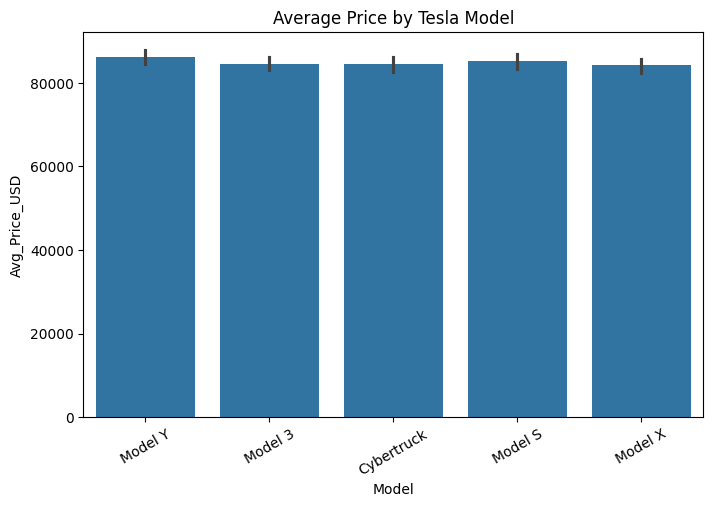

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Model", y="Avg_Price_USD")
plt.title("Average Price by Tesla Model")
plt.xticks(rotation=30)
plt.show()

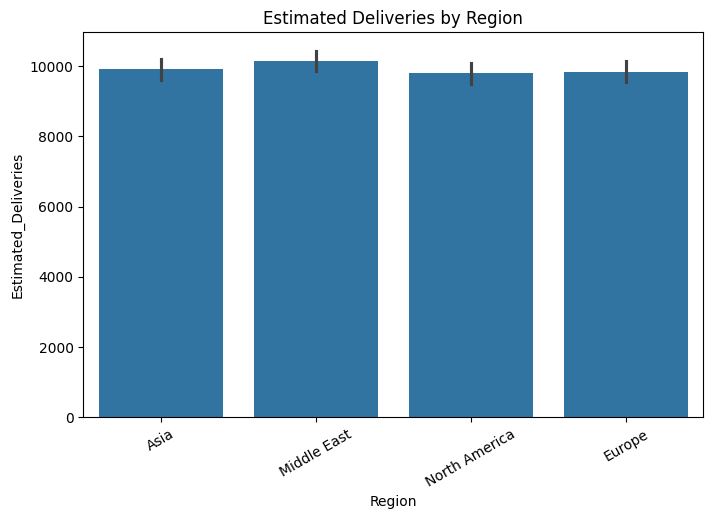

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Region", y="Estimated_Deliveries")
plt.title("Estimated Deliveries by Region")
plt.xticks(rotation=30)
plt.show()

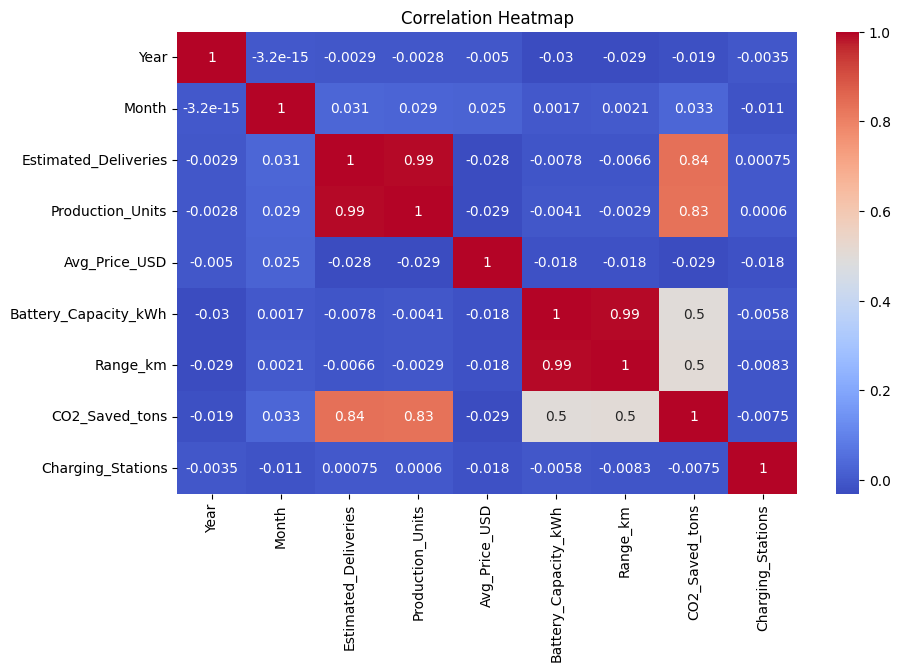

In [21]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

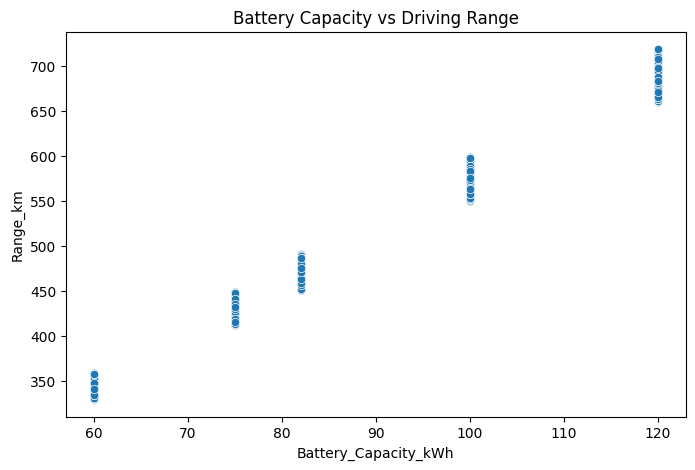

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Battery_Capacity_kWh",
    y="Range_km"
)

plt.title("Battery Capacity vs Driving Range")
plt.show()

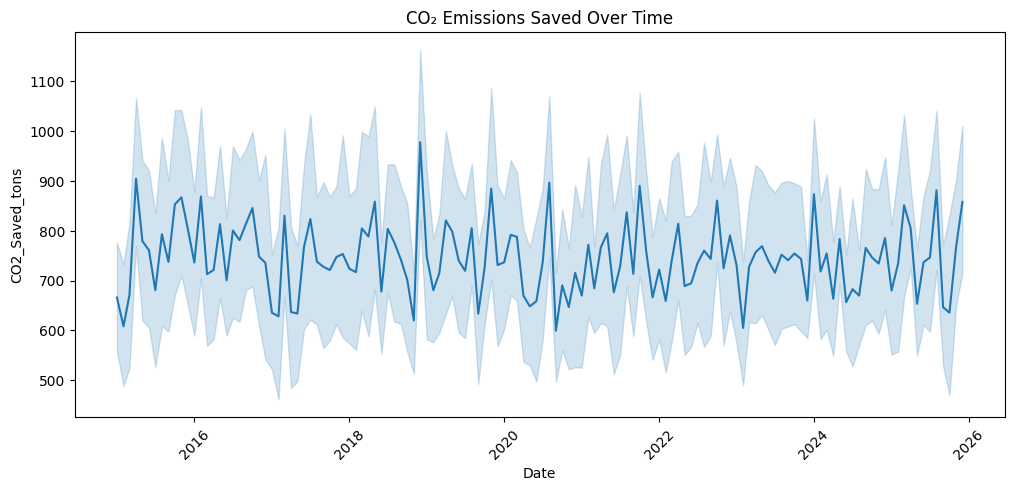

In [23]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x="Date",
    y="CO2_Saved_tons"
)

plt.title("CO₂ Emissions Saved Over Time")
plt.xticks(rotation=45)
plt.show()

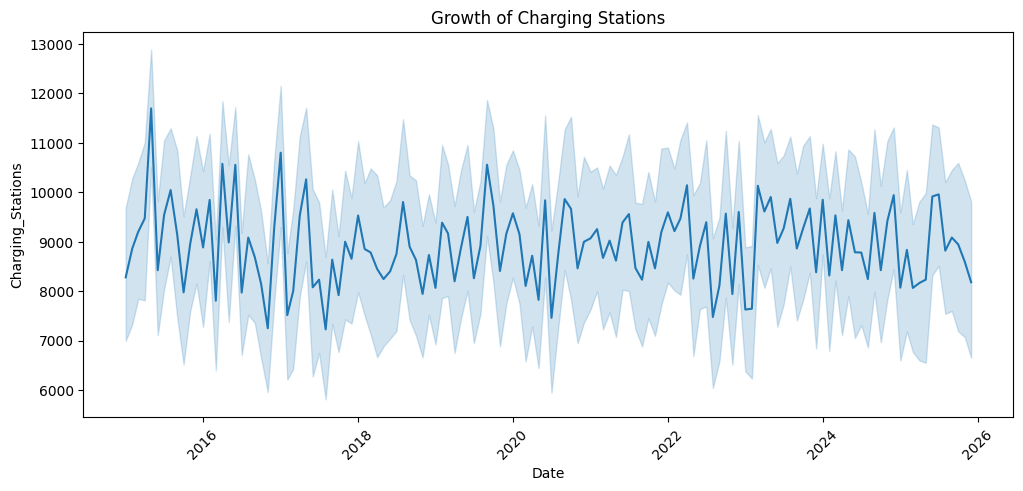

In [24]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x="Date",
    y="Charging_Stations"
)

plt.title("Growth of Charging Stations")
plt.xticks(rotation=45)
plt.show()

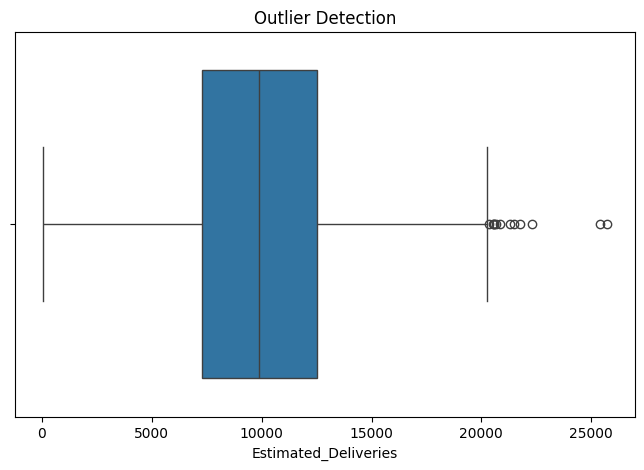

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Estimated_Deliveries"])

plt.title("Outlier Detection")
plt.show()

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Region"] = le.fit_transform(df["Region"])
df["Model"] = le.fit_transform(df["Model"])
df["Source_Type"] = le.fit_transform(df["Source_Type"])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
872,2015,1,0,4,12446,13885,55183.13,60,340,634.75,2,4390,2015-01-01
2354,2015,1,2,1,11446,12752,89289.40,100,588,1009.54,0,8925,2015-01-01
2312,2015,1,2,0,8803,9344,102888.58,60,336,443.67,1,3923,2015-01-01
2293,2015,1,3,0,6367,6802,104962.32,82,459,438.37,0,9170,2015-01-01
2215,2015,1,0,1,8795,9165,87988.73,82,456,601.58,2,12626,2015-01-01


In [27]:
# Quarter of the year
df["Quarter"] = df["Date"].dt.quarter

# Month name
df["Month_Name"] = df["Date"].dt.month_name()

# Delivery Efficiency
df["Delivery_Efficiency"] = (
    df["Estimated_Deliveries"] / df["Production_Units"]
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Name,Delivery_Efficiency
872,2015,1,0,4,12446,13885,55183.13,60,340,634.75,2,4390,2015-01-01,1,January,0.896363
2354,2015,1,2,1,11446,12752,89289.40,100,588,1009.54,0,8925,2015-01-01,1,January,0.897585
2312,2015,1,2,0,8803,9344,102888.58,60,336,443.67,1,3923,2015-01-01,1,January,0.942102
2293,2015,1,3,0,6367,6802,104962.32,82,459,438.37,0,9170,2015-01-01,1,January,0.936048
2215,2015,1,0,1,8795,9165,87988.73,82,456,601.58,2,12626,2015-01-01,1,January,0.959629


In [33]:
X = df[[
    "Year",
    "Month",
    "Region",
    "Model",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations"
]]

y = df["Estimated_Deliveries"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (2112, 10)
Testing Samples: (528, 10)


In [34]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("Linear Regression Results")

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression Results
MAE : 311.94051741757005
RMSE: 381.4018735342086
R2 Score: 0.9902910109039496


In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [38]:
print("Random Forest Results")

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results
MAE : 296.0864015151515
RMSE: 384.79559804672454
R2 Score: 0.9901174604839531


In [39]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Score: 0.9883388438893289


In [40]:
from statsmodels.tsa.arima.model import ARIMA

# Monthly total deliveries
ts = df.groupby("Date")["Estimated_Deliveries"].sum()

ts.head()

,Estimated_Deliveries
Date,
2015-01-01,183180
2015-02-01,165053
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264


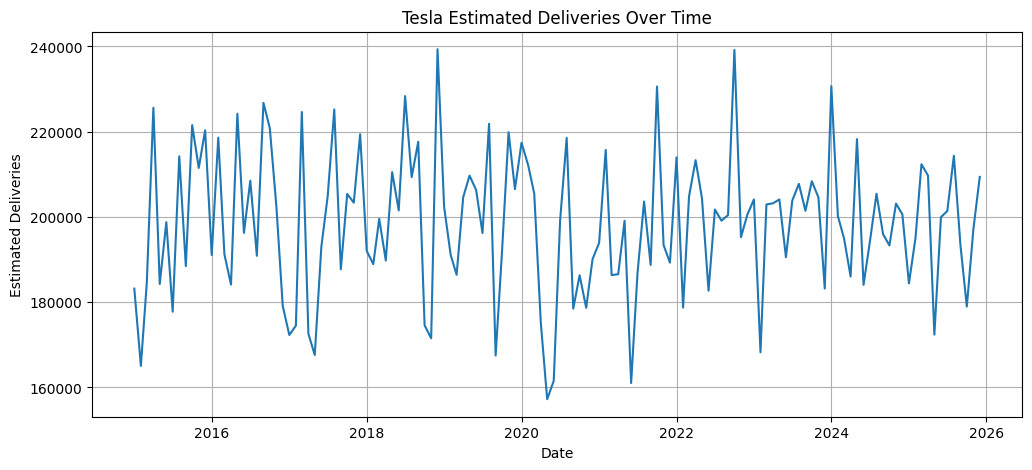

In [41]:
plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title("Tesla Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.grid(True)
plt.show()

In [42]:
model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1488.634
Date:                  Sun, 28 Jun 2026   AIC                           2983.269
Time:                          09:16:20   BIC                           2991.895
Sample:                      01-01-2015   HQIC                          2986.774
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1592      0.074      2.158      0.031       0.015       0.304
ma.L1         -0.7277      0.063    -11.529      0.000      -0.851      -0.604
sigma2       3.58e+08   1.93e-11   1

In [43]:
forecast = model_fit.forecast(steps=12)

forecast

,predicted_mean
2026-01-01,201130.711312
2026-02-01,199815.368230
2026-03-01,199605.917024
2026-04-01,199572.564655
2026-05-01,199567.253726
2026-06-01,199566.408030
2026-07-01,199566.273364
2026-08-01,199566.251920
2026-09-01,199566.248506
2026-10-01,199566.247962


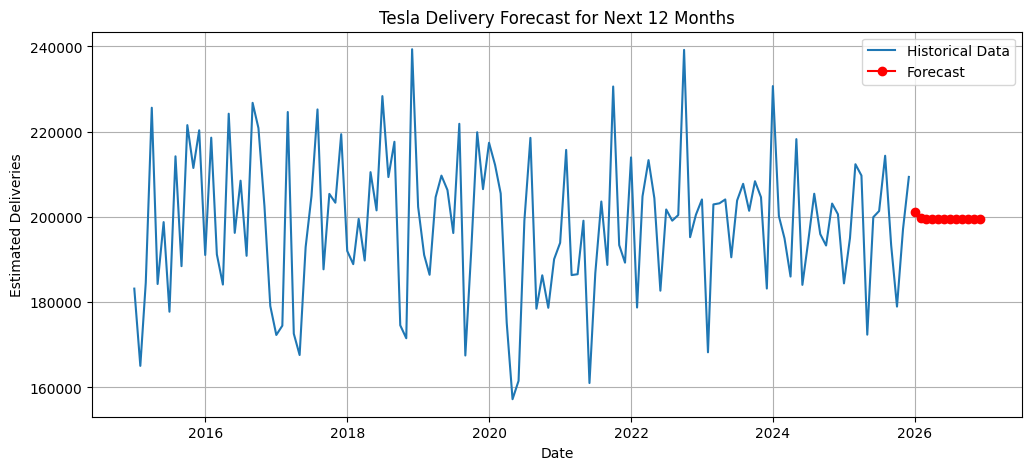

In [44]:
plt.figure(figsize=(12,5))

plt.plot(ts, label="Historical Data")

future_dates = pd.date_range(
    start=ts.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

plt.plot(future_dates, forecast,
         color="red",
         marker="o",
         label="Forecast")

plt.title("Tesla Delivery Forecast for Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()
plt.grid(True)

plt.show()

In [45]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,311.940517,381.401874,0.990291
1,Random Forest,296.086402,384.795598,0.990117
